# Evolución de una Acción con Qlib
Este notebook recupera los datos de una acción usando Qlib y muestra una gráfica de la evolución de su valor de cierre desde el 1 de enero de 2020.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import qlib
from qlib.data import D
from qlib.config import REG_US
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configurar el ticker y la fecha de inicio
TICKER = "^GSPC"  # Cambia esto por el ticker que desees analizar (ej: TSLA, MSFT, NVO, GLD)
START_DATE = "2020-01-01"

# Inicializar Qlib con los datos de mercado de US
# Nota: provider_uri debe apuntar a donde tengas descargados los datos de Qlib.
provider_uri = '~/.qlib/qlib_data/us_data'
try:
    qlib.init(provider_uri=provider_uri, region=REG_US)
    print("Qlib inicializado correctamente.")
except Exception as e:
    print(f"Aviso al inicializar Qlib: {e}")

[3420731:MainThread](2026-04-13 16:41:24,932) INFO - qlib.Initialization - [config.py:453] - default_conf: client.
[3420731:MainThread](2026-04-13 16:41:25,932) INFO - qlib.Initialization - [__init__.py:82] - qlib successfully initialized based on client settings.
[3420731:MainThread](2026-04-13 16:41:25,936) INFO - qlib.Initialization - [__init__.py:84] - data_path={'__DEFAULT_FREQ': PosixPath('/home/toni/.qlib/qlib_data/us_data')}


Qlib inicializado correctamente.


Recuperando datos para ^GSPC desde 2020-01-01...


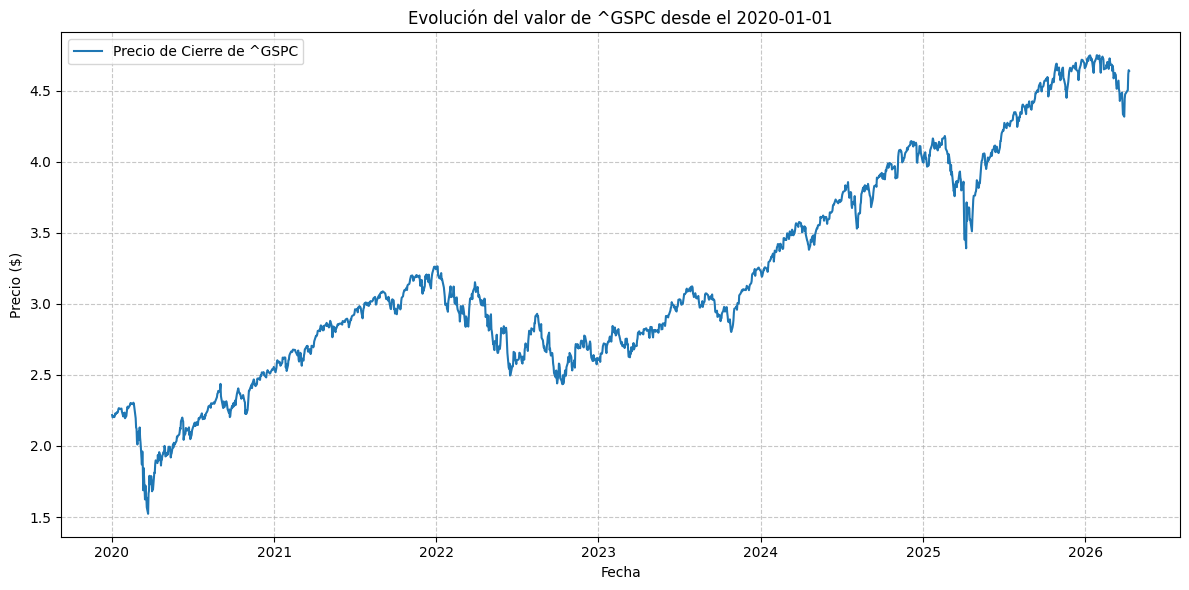

In [3]:
print(f"Recuperando datos para {TICKER} desde {START_DATE}...")

# Recuperar el precio de cierre ($close) de la acción
instruments = [TICKER]
fields = ['$close']
try:
    df = D.features(instruments, fields, start_time=START_DATE)
except Exception as e:
    print(f"Error al recuperar datos: {e}")
    df = None

if df is not None and not df.empty:
    # Qlib devuelve un DataFrame con MultiIndex (instrument, datetime).
    # Seleccionamos solo los datos del ticker especificado
    df_ticker = df.loc[TICKER]
    
    # Crear la gráfica
    plt.figure(figsize=(12, 6))
    plt.plot(df_ticker.index, df_ticker['$close'], label=f'Precio de Cierre de {TICKER}', color='#1f77b4')
    
    plt.title(f'Evolución del valor de {TICKER} desde el {START_DATE}')
    plt.xlabel('Fecha')
    plt.ylabel('Precio ($)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    
    plt.show()
else:
    print(f"No se encontraron datos para el ticker {TICKER} desde {START_DATE}.")

In [4]:
# Configurar pandas para mostrar todas las columnas sin ocultarlas
pd.set_option('display.max_columns', None)

# Especificar las columnas (features) que queremos traer de Qlib
instruments = [TICKER]
fields = ['$open', '$high', '$low', '$close', '$volume', '$amount', '$factor']

print(f"Recuperando todas las columnas para {TICKER}...")
df_all = D.features(instruments, fields, start_time=START_DATE)

if df_all is not None and not df_all.empty:
    # Qlib devuelve un MultiIndex, seleccionamos el ticker en cuestión
    df_ticker_all = df_all.loc[TICKER]
    df_ticker_all['price_closed'] = df_ticker_all['$close'] / df_ticker_all['$factor']
    
    # Extraer exactamente los últimos 40 registros
    df_40 = df_ticker_all.tail(40)
    
    print(f"Últimos 40 registros de {TICKER} con las columnas extraídas:")
    display(df_40)
else:
    print(f"No se encontraron datos para {TICKER}.")

Recuperando todas las columnas para ^GSPC...
Últimos 40 registros de ^GSPC con las columnas extraídas:


,$open,$high,$low,$close,$volume,$amount,$factor,price_closed
datetime,,,,,,,,
2026-02-12,4.735436,4.746109,4.644574,4.650508,1.045915e+13,NaN,0.000681,6832.759277
2026-02-13,4.651536,4.683995,4.624502,4.652830,8.401701e+12,NaN,0.000681,6836.169922
2026-02-17,4.641729,4.673807,4.611537,4.657628,7.961102e+12,NaN,0.000681,6843.219727
2026-02-18,4.665972,4.702481,4.662011,4.683553,7.490472e+12,NaN,0.000681,6881.309570
2026-02-19,4.669961,4.682062,4.650713,4.670335,7.569121e+12,NaN,0.000681,6861.890137
2026-02-20,4.657655,4.707068,4.652939,4.702746,7.981671e+12,NaN,0.000681,6909.509277
2026-02-23,4.697124,4.707817,4.641701,4.653905,8.284146e+12,NaN,0.000681,6837.749512
2026-02-24,4.653646,4.695709,4.638714,4.689515,7.737203e+12,NaN,0.000681,6890.069824
2026-02-25,4.706585,4.732013,4.706585,4.727671,7.828252e+12,NaN,0.000681,6946.129883


In [5]:
# Extraer el precio de cierre y el factor de ajuste
df = D.features(['NVO'], ['$close', '$factor'], start_time='2026-03-01', end_time='2026-12-31')
df['price_closed'] = df['$close'] / df['$factor']
print(df)

                          $close   $factor  price_closed
instrument datetime                                     
NVO        2026-03-02  46.209019  1.223756     37.759998
           2026-03-03  44.862888  1.223756     36.660000
           2026-03-04  47.114601  1.223756     38.500000
           2026-03-05  47.812141  1.223756     39.070000
           2026-03-06  47.212502  1.223756     38.580002
           2026-03-09  48.681011  1.223756     39.779999
           2026-03-10  47.383831  1.223756     38.720005
           2026-03-11  47.518444  1.223756     38.830002
           2026-03-12  46.527199  1.223756     38.019997
           2026-03-13  46.453770  1.223756     37.959999
           2026-03-16  47.212502  1.223756     38.580002
           2026-03-17  47.028938  1.223756     38.430000
           2026-03-18  45.829659  1.223756     37.449997
           2026-03-19  45.376869  1.223756     37.080002
           2026-03-20  44.703800  1.223756     36.529999
           2026-03-23  45.05868

In [6]:
# Extraer el precio de cierre y el factor de ajuste
df = D.features(['JPM'], ['$close', '$factor'], start_time='2026-03-01', end_time='2026-12-31')
df['price_closed'] = df['$close'] / df['$factor']
print(df)

                          $close   $factor  price_closed
instrument datetime                                     
JPM        2026-03-02  12.183370  0.040944    297.559998
           2026-03-03  12.293919  0.040944    300.260010
           2026-03-04  12.258299  0.040944    299.390045
           2026-03-05  12.019182  0.040944    293.549988
           2026-03-06  11.852540  0.040944    289.480011
           2026-03-09  11.870557  0.040944    289.920044
           2026-03-10  11.821832  0.040944    288.730011
           2026-03-11  11.772288  0.040944    287.519989
           2026-03-12  11.582719  0.040944    282.890015
           2026-03-13  11.605237  0.040944    283.440002
           2026-03-16  11.716605  0.040944    286.160004
           2026-03-17  11.746494  0.040944    286.889984
           2026-03-18  11.781296  0.040944    287.739960
           2026-03-19  11.790714  0.040944    287.970001
           2026-03-20  11.732983  0.040944    286.559998
           2026-03-23  11.87014

In [7]:
# Extraer el precio de cierre y el factor de ajuste
df = D.features(['^NDX'], ['$close', '$factor'], start_time='2026-03-01', end_time='2026-12-31')
df['price_closed'] = df['$close'] / df['$factor']
print(df)

                         $close  $factor  price_closed
instrument datetime                                   
^NDX       2026-03-02  6.740492  0.00027  24992.599609
           2026-03-03  6.666994  0.00027  24720.080078
           2026-03-04  6.767754  0.00027  25093.679688
           2026-03-05  6.747993  0.00027  25020.410156
           2026-03-06  6.646211  0.00027  24643.019531
           2026-03-09  6.733655  0.00027  24967.250000
           2026-03-10  6.730748  0.00027  24956.470703
           2026-03-11  6.733051  0.00027  24965.009766
           2026-03-12  6.616695  0.00027  24533.580078
           2026-03-13  6.575471  0.00027  24380.730469
           2026-03-16  6.649533  0.00027  24655.339844
           2026-03-17  6.683268  0.00027  24780.419922
           2026-03-18  6.587435  0.00027  24425.089844
           2026-03-19  6.568607  0.00027  24355.279297
           2026-03-20  6.445320  0.00027  23898.150391
           2026-03-23  6.523651  0.00027  24188.589844
          

In [8]:
# Extraer el precio de cierre y el factor de ajuste
df = D.features(['MSFT'], ['$close', '$factor'], start_time='2026-03-01', end_time='2026-12-31')
df['price_closed'] = df['$close'] / df['$factor']
print(df)

                          $close   $factor  price_closed
instrument datetime                                     
MSFT       2026-03-02  11.202297  0.028108    398.549988
           2026-03-03  11.353517  0.028108    403.929993
           2026-03-04  11.389214  0.028108    405.200012
           2026-03-05  11.543243  0.028108    410.680023
           2026-03-06  11.494898  0.028108    408.959991
           2026-03-09  11.507546  0.028108    409.410004
           2026-03-10  11.404954  0.028108    405.760010
           2026-03-11  11.380219  0.028108    404.880035
           2026-03-12  11.295334  0.028108    401.860016
           2026-03-13  11.117974  0.028108    395.549988
           2026-03-16  11.241649  0.028108    399.950012
           2026-03-17  11.226471  0.028108    399.410034
           2026-03-18  11.012290  0.028108    391.790009
           2026-03-19  10.934432  0.028108    389.020020
           2026-03-20  10.733462  0.028108    381.869995
           2026-03-23  10.76522